In [22]:
folder = "../output/dombft_long_28800"

import os
import glob


client_logs = []
for filepath in glob.glob(os.path.join(folder, "client*.log")):
    with open(filepath, 'r') as f:
        client_logs.append(f.read())


In [23]:
PATHS = ["fast", "normal", "slow", "missed"]

In [24]:

# First, split file i
def parse_client_logs(logs):
    summaries = {}

    # Skip first non valid section and first and last minutes
    for section in logs.split("Minute ending ")[3: -1]:
        time = section.split(" ")[0] 

        summaries[time] = {}
        
        for line in section.split("\n"):
            if len(line) == 0 or line[0] != '\t': continue

            tag, value = line.split("=")
            tag = tag.strip()
            value = float(value.strip().split(" ")[0])
            
            summaries[time][tag] = value

    return summaries


parsed_clients = [parse_client_logs(cl) for cl in client_logs]

In [25]:
total_commits = 0
total_fast_commits = 0
total_latency = 0

max_commits = 0
max_commits_time = None


for time in parsed_clients[0]:
    non_fast_path = False
    
    summaries = [pcl[time] for pcl in parsed_clients if time in pcl]

    
    time_commits = 0
    
    for s in summaries:
        time_commits  += s["num_commits"]
        total_fast_commits += s["fast_num_commits"]
        total_commits += s["num_commits"]
        total_latency += s["avg_latency"] * s["num_commits"]

        if not (s["normal_num_commits"] == 0 and s["slow_num_commits"] == 0 and s["missed_num_commits"] == 0):
            non_fast_path = True    
    if time_commits > max_commits:
        max_commits = time_commits
        max_commits_time = time


print(f"Throughput: {total_commits/(len(parsed_clients[0]) * 60):.0f}")
print(f"Avg Latency: {total_latency/total_commits:.0f}")

print(f"fast path commit ratio {total_fast_commits/total_commits:.4f}")

print(f"Best minute at {max_commits_time}")
print(parsed_clients[0][max_commits_time])
# if max_commits_time:
#     for pc in parsed_clients:
#         print(pc[max_commits_time])


Throughput: 5915
Avg Latency: 1873615
fast path commit ratio 0.8724
Best minute at 12:28
{'num_commits': 30147.0, 'avg_latency': 840986.6862706074, 'fast_num_commits': 28620.0, 'fast_avg_latency': 801677.0, 'fast_p95_latency': 3387321.0, 'fast_p99_latency': 4406630.0, 'normal_num_commits': 979.0, 'normal_avg_latency': 1149342.0, 'normal_p95_latency': 3510011.0, 'normal_p99_latency': 3555180.0, 'slow_num_commits': 548.0, 'slow_avg_latency': 2343130.0, 'slow_p95_latency': 3147755.0, 'slow_p99_latency': 3165939.0, 'missed_num_commits': 0.0}


In [26]:

num_commits = 0
latency = 0


for pcl in parsed_clients:
    if max_commits_time not in pcl:
        continue
    
    num_commits += pcl[max_commits_time]["num_commits"]
    latency += pcl[max_commits_time]["avg_latency"] * pcl[max_commits_time]["num_commits"]


print(f"Best Case throughput: {num_commits/60:.0f}")
print(f"Best Minute avg latency: {latency/num_commits:.0f}")



Best Case throughput: 12100
Best Minute avg latency: 815284


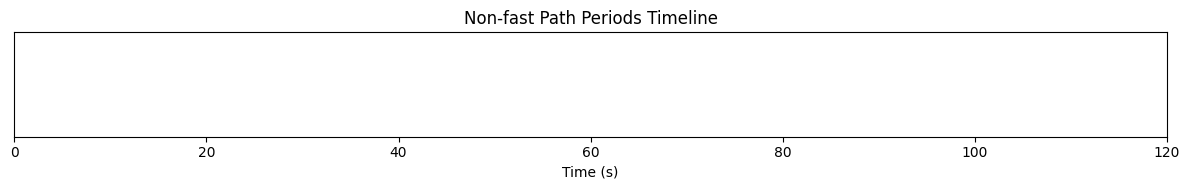

In [6]:
# Create diagram of period

import re
import matplotlib.pyplot as plt

# Thanks chatGPT!

period_end = 120
with open("/home/dqian/Projects/bft/DOM-BFT/results_nov2025_v2/n_nng/dombft_n4_sr8000.out", 'r') as f:
    data = f.read()


periods = []


start_pattern = re.compile(r"Starting non-fast period at ([\d.]+)")
pattern = re.compile(r"start=([\d.]+)\s+end=([\d.]+)")
last_start = 0
for line in data.strip().splitlines():
    match = pattern.search(line)
    if match:
        start = float(match.group(1))
        end = float(match.group(2))
        periods.append((start, end))

    match = start_pattern.search(line)
    if match:
        last_start = float(match.group(1))


if len(periods) > 0 and last_start > periods[-1][1]:
    periods.append((last_start, period_end))


# Plotting
fig, ax = plt.subplots(figsize=(12, 2))
for start, end in periods:
    ax.axvspan(start, end, color='red', alpha=0.3)

# rate = folder.split("_")[-1]

# Customization
ax.set_ylim(0, 1)
ax.set_xlim(0,120)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title(f"Non-fast Path Periods Timeline")# rate={rate}")
plt.tight_layout()

plt.savefig("extended_timeline.png")
plt.show()



In [7]:
print(f"Percent in fast path: {1- sum(end - start for (start, end) in periods) / 120:.2f}")

Percent in fast path: 1.00


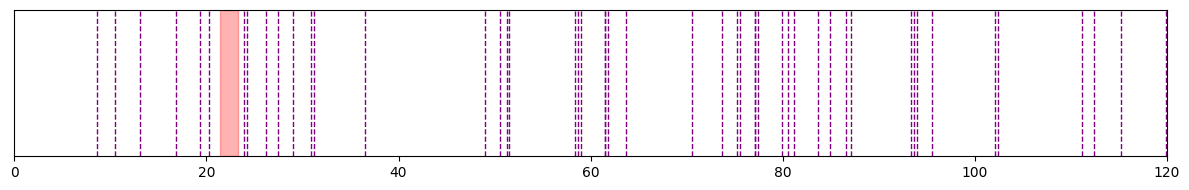

In [12]:
import re
import matplotlib.pyplot as plt
from datetime import datetime

# ---------------------------------------
# CONFIG
# ---------------------------------------
LOGFILE = "../results_nov2025_v2/n_nng/dombft_n10_sr8000.out"
PERIOD_END = 120   # used if a repair_start has no matching repair_end
# ---------------------------------------

# Extract HH:MM:SS.xxx from the log lines
timestamp_re = re.compile(r"I\d+\s+(\d{2}:\d{2}:\d{2}\.\d{6})")

# Detect repair start/end markers
repair_start_re = re.compile(r"event=repair_start replica_id=0")
repair_end_re   = re.compile(r"event=repair_end replica_id=0")
align_re = re.compile(r"event=align")



# Convert wall clock timestamp → seconds since beginning of file
def ts_to_seconds(ts_string, base_ts):
    t = datetime.strptime(ts_string, "%H:%M:%S.%f")
    delta = t - base_ts
    return delta.total_seconds()

periods = []
aligns = []
current_start = None
base_ts = None

with open(LOGFILE, "r") as f:
    for line in f:
        ts_match = timestamp_re.search(line)
        if not ts_match:
            continue

        ts_str = ts_match.group(1)
        ts = datetime.strptime(ts_str, "%H:%M:%S.%f")

        if base_ts is None:
            base_ts = ts

        t_rel = (ts - base_ts).total_seconds()


        # repair_start
        if repair_start_re.search(line):
            current_start = t_rel

        # repair_end
        if repair_end_re.search(line):
            if current_start is not None:
                periods.append((current_start, t_rel))
                current_start = None

        if align_re.search(line):
            aligns.append(t_rel)

# If log ends during a repair period → extend to PERIOD_END
if current_start is not None:
    periods.append((current_start, PERIOD_END))

slow_path_time = 0
for (ps, pe) in periods:
    (pe - ps)

# ---------------------------------------
# Plot
# ---------------------------------------
fig, ax = plt.subplots(figsize=(12, 2))

for s, e in periods:
    ax.axvspan(s, e, color='red', alpha=0.3)
    
for t in aligns:
    ax.axvline(t, color='purple', linestyle='--', linewidth=1)

ax.set_ylim(0, 1)
ax.set_xlim(0, PERIOD_END)
ax.set_yticks([])
# ax.set_xlabel("Time (s)")
# ax.set_title("Repair Periods Timeline")

plt.tight_layout()
plt.savefig("repair_timeline.png")
plt.show()
